In [44]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as sci
import statsmodels.tsa.stattools as sm
from scipy.optimize import brentq
%matplotlib inline

In [45]:
S = 100
K = 100
T = 1
μ = r = 0.05
ν0 = 0.04
Θ = 0.04
κ = 2.0
ξ = 0.5
ρ = 0.7
N = 252
n_sims = 100000
dt = T / N

K_min = 80
K_max = 150

### Code

In [46]:
def d1(S, K, T, r, sigma):
    return (np.log(S/K) + (r + (sigma **2 / 2)) * T) / (sigma * np.sqrt(T))

def d2(S, K, T, r, sigma):
    return d1(S, K, T, r, sigma) - sigma * np.sqrt(T)


def call_price(S, K, T, r, sigma):
    return sci.norm.cdf(d1(S, K, T, r, sigma))*S - sci.norm.cdf(d2(S, K, T, r, sigma))*K*np.exp(-r*T)

In [47]:
def dSt(μ, St, dt, ν_t, dWs):
    return μ * St * dt + np.sqrt(ν_t) * St * dWs

In [48]:
def dν_t(κ, Θ, ν_t, dt, ξ, dWν):
    return κ * (Θ - ν_t) * dt + ξ * np.sqrt(ν_t) * dWν 

In [49]:
def correlated_noise(n_sims, N, ρ, dt):
    z1 = np.random.randn(n_sims, N)
    z2 = np.random.randn(n_sims, N)
    dWs = np.sqrt(dt) * z1
    dWν = np.sqrt(dt) * (ρ * z1 + np.sqrt(1 - ρ **2) * z2)
    return dWs, dWν 

In [50]:
def gen_νs(κ, Θ, ν_t, dt, ξ, dWν, N):
    νs = np.zeros((n_sims, N))
    νs[:, 0] = ν_t

    for i in range(1, N):
        νs[:, i] = νs[:, i-1] + dν_t(κ, Θ, νs[:, i-1], dt, ξ, dWν[:, i-1])
        νs[:, i] = np.maximum(0, νs[:, i])

    return νs

def gen_Sts(μ, St, dt, νs, dWs, N):
    Sts = np.zeros((n_sims, N))
    Sts[:, 0] = St

    for i in range(1, N):
        Sts[:, i] = Sts[:, i-1] + dSt(μ, Sts[:, i-1], dt, νs[:, i-1], dWs[:, i-1])
        Sts[:, i] = np.maximum(0, Sts[:, i])

    return Sts

In [51]:
dWs, dWν = correlated_noise(n_sims, N, ρ, dt)

# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 3));
# ax1.plot(dWs[0]);
# ax2.plot(dWν[0]);
# plt.show();


In [52]:
np.mean([np.corrcoef(dWs[i], dWν[i])[0,1] for i in range(N)])

np.float64(0.7040490938779259)

In [53]:
νs = gen_νs(κ, Θ, ν0, dt, ξ, dWν, N)
Sts = gen_Sts(μ, S, dt, νs, dWs, N)

In [54]:
# plt.plot(Sts.T);
# plt.savefig("Heston fan.png")

In [55]:
print(f"Heston model MC gives {np.mean(np.maximum(0, Sts[:, -1] - K) * np.exp(-r * T)):.2f} while BS gives {call_price(S, K, T, r, np.sqrt(ν0)):.2f}")

Heston model MC gives 9.56 while BS gives 10.45


In [56]:
Ks = np.arange(K_min, K_max, 1)
payoffs = np.maximum(0, Sts[:, -1, np.newaxis] - Ks) * np.exp(-r * T)
prices = np.mean(payoffs, axis=0)

In [57]:
# plt.scatter(Ks, prices)

In [58]:
def imply(K, x):
    try: return brentq(lambda σ: call_price(S, K, T, r, σ) - x, 0.0001, 2)
    except ValueError: return 0

In [59]:
IVs = [imply(K, price) for K, price in zip(Ks, prices)]
print(IVs)

[0.1303701736844984, 0.1344668645568283, 0.13753756906463704, 0.14007749292598784, 0.1423143063775752, 0.14436972739176948, 0.14633540600277056, 0.14827271079890664, 0.15022422130591634, 0.15220514554780673, 0.1542343828489518, 0.15633627482195842, 0.15846527228420623, 0.160616270896416, 0.16279315528594368, 0.16500631757591927, 0.16721953135939271, 0.16944474858511438, 0.17167274636846022, 0.17392086916607533, 0.17618991423593708, 0.17845897736731584, 0.1807282171296647, 0.1829890659021067, 0.1852436628552787, 0.18747201750719644, 0.18968491359426695, 0.1918814681013988, 0.19405351621442385, 0.19619969152709393, 0.19832457677914686, 0.20043239377480274, 0.20252087015071116, 0.20459319460696798, 0.2066352774973984, 0.20865614069406196, 0.21064291508667568, 0.2125891803990067, 0.21450790285921364, 0.2163994508540173, 0.2182708199952089, 0.22011595563203884, 0.22194116641454986, 0.2237528618912334, 0.225541713549429, 0.22730609737140087, 0.22904661410445834, 0.23076915247978644, 0.232475

### Plot

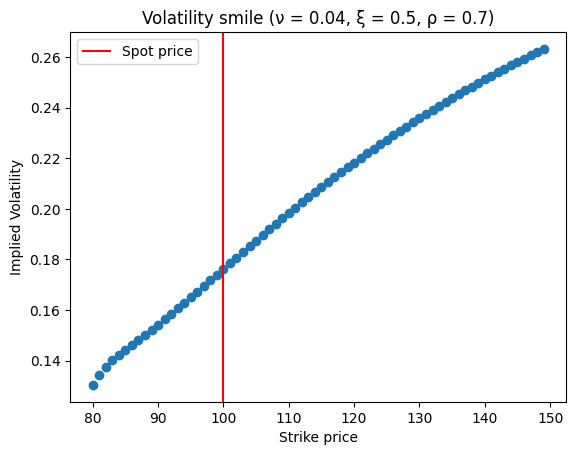

In [60]:
plt.scatter(Ks, IVs)
plt.axvline(S, color="red",label="Spot price")
plt.xlabel("Strike price")
plt.ylabel("Implied Volatility")
plt.legend()
plt.title(f"Volatility smile (ν = {ν0}, ξ = {ξ}, ρ = {ρ})")
plt.savefig("Heston derived smile.png")

In [61]:
# fig, ax = plt.subplots(3, 3, figsize=(12, 12))
# ξs = [0.2, 0.5, 0.]
# for i in range(3):
#     for j in range(3):

In [62]:
def heston(S, T, r, ν0, Θ, κ, ξ, ρ, N, n_sims, K_min, K_max):
    dt = T / N
    
    dWs, dWν = correlated_noise(n_sims, N, ρ, dt)
    
    νs = gen_νs(κ, Θ, ν0, dt, ξ, dWν, N)
    
    Sts = gen_Sts(r, S, dt, νs, dWs, N)
    
    Ks = np.arange(K_min, K_max, 1)
    payoffs = np.maximum(0, Sts[:, -1, np.newaxis] - Ks) * np.exp(-r * T)
    prices = np.mean(payoffs, axis=0)    
    IVs = [imply(K, price) for K, price in zip(Ks, prices)]
    
    return Ks, IVs

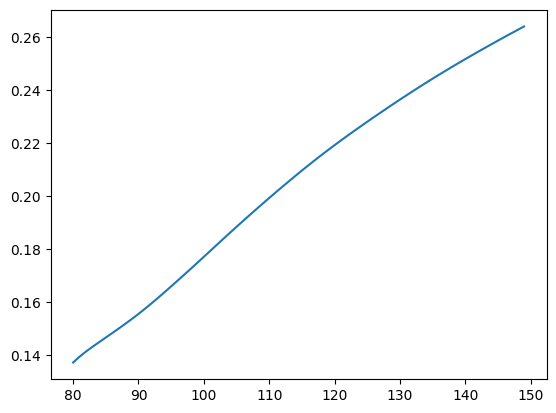

In [63]:
h = heston(S, T, r, ν0, Θ, κ, ξ, ρ, N, n_sims, K_min, K_max)
plt.plot(h[0], h[1]);

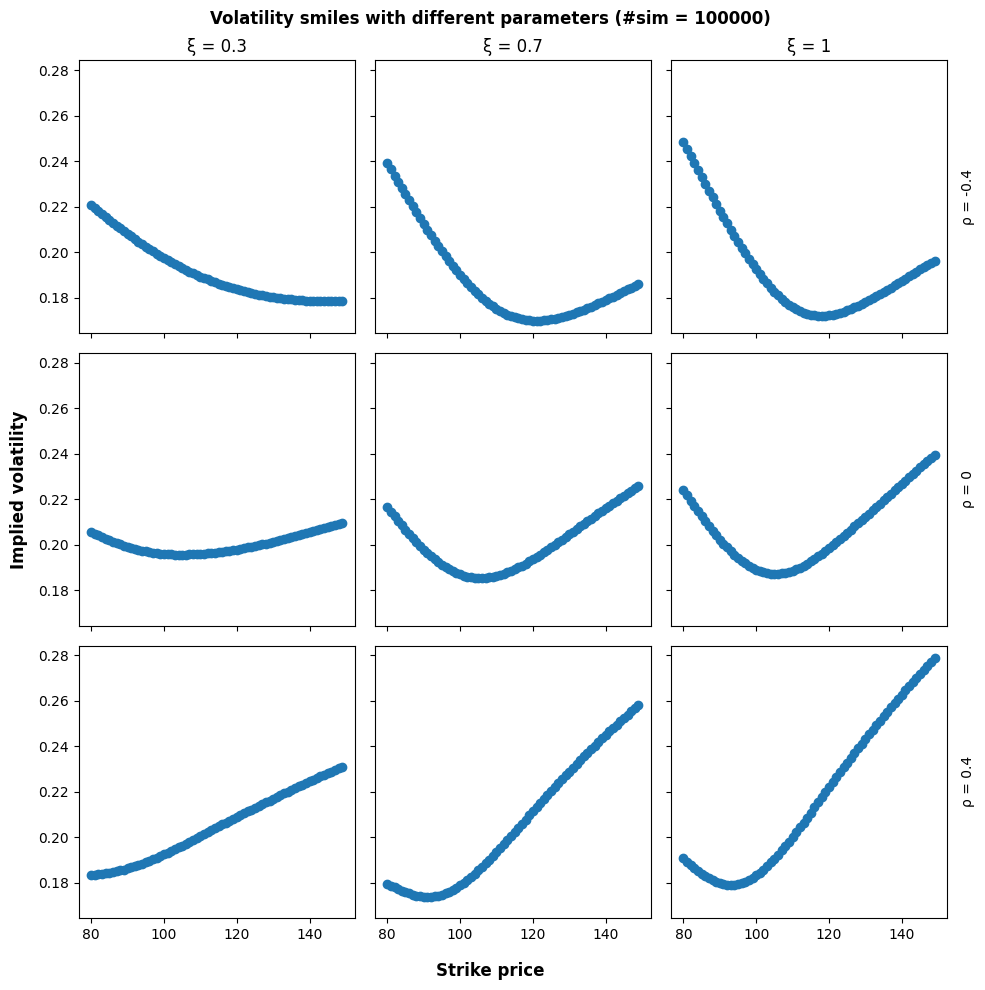

In [64]:
fig, ax = plt.subplots(3, 3, figsize=(10, 10), sharex=True, sharey=True)

ξs = [0.3, 0.7, 1]
ρs = [-0.4, 0, 0.4]

for i in range(3):
    for j in range(3):
        Ks, IVs = heston(S, T, r, ν0, Θ, κ, ξs[j], ρs[i], N, n_sims, K_min, K_max)
        ax[i, j].scatter(Ks, IVs)


for j, ξ_val in enumerate(ξs):
    ax[0, j].set_title(f'ξ = {ξ_val}')

for i, ρ_val in enumerate(ρs):
    ax[i, -1].yaxis.set_label_position('right')

    ax[i, -1].set_ylabel(f'ρ = {ρ_val}', rotation=90, labelpad=10)


fig.supylabel("Implied volatility", fontweight="bold")
fig.supxlabel("Strike price", fontweight="bold")
fig.suptitle(f"Volatility smiles with different parameters (#sim = {n_sims})", fontsize="large", fontweight="bold")
fig.tight_layout()
fig.savefig("Heston smiles.png")